In [131]:
# import excle file and read data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import warnings
import subprocess
warnings.filterwarnings("ignore")
# read data
subprocess.check_call(['pip', 'install', 'openpyxl'])
data_log = pd.read_excel('ICT001 S1 2025 Logs RELEASED V1.0.xlsx', sheet_name='Sheet1', engine='openpyxl')

In [132]:
data_log.head()

,Time,User full name,Username,Affected user,Event context,Component,Event name,Description,Origin,IP Address
0,"13/11/25, 09:55:28",John Surname046,20220829@murdoch.edu.au,-,"Unit: ICT001 Theory of Programming (S1, 2025)",System,Unit viewed,The user with id '211844' viewed the course wi...,web,NaN
1,"20/09/25, 19:30:02",John Surname111,15925111@student.murdoch.edu.au,-,"Unit: ICT001 Theory of Programming (S1, 2025)",System,Unit viewed,The user with id '251248' viewed the course wi...,web,NaN
2,"20/09/25, 19:29:35",John Surname111,15925111@student.murdoch.edu.au,-,File: Lab description (PDF),File,Unit module viewed,The user with id '251248' viewed the 'resource...,web,NaN
3,"20/09/25, 19:29:08",John Surname111,15925111@student.murdoch.edu.au,-,File: Solutions (Hidden from Students),File,Unit module viewed,The user with id '251248' viewed the 'resource...,web,NaN
4,"20/09/25, 19:29:04",John Surname111,15925111@student.murdoch.edu.au,-,"Unit: ICT001 Theory of Programming (S1, 2025)",System,Unit viewed,The user with id '251248' viewed the course wi...,web,NaN


In [133]:
# compare fields data_log.columns vs mdl_log.columns

mdl_log = pd.read_csv('mdl_logstore_standard_log.csv')
print("Data Log Columns:")
print(data_log.columns)
print("\nMDL Log Columns:")
print(mdl_log.columns)  

Data Log Columns:
Index(['Time', 'User full name', 'Username', 'Affected user', 'Event context',
       'Component', 'Event name', 'Description', 'Origin', 'IP Address'],
      dtype='object')

MDL Log Columns:
Index(['id', 'eventname', 'component', 'action', 'target', 'objecttable',
       'objectid', 'crud', 'edulevel', 'contextid', 'contextlevel',
       'contextinstanceid', 'userid', 'courseid', 'relateduserid', 'anonymous',
       'other', 'timecreated', 'origin', 'ip', 'realuserid'],
      dtype='object')


In [134]:
# count how many times each user appears in data_log
if 'User ID' in data_log.columns:
    user_counts = data_log['User ID'].value_counts()
elif 'Username' in data_log.columns:
    user_counts = data_log['Username'].value_counts()
elif 'User full name' in data_log.columns:
    user_counts = data_log['User full name'].value_counts()
else:
    user_ids = data_log['Description'].str.extract(r"id '(\d+)'", expand=False)
    user_counts = user_ids.value_counts()
print(user_counts)  

Username
15925004@student.murdoch.edu.au    1294
15925153@student.murdoch.edu.au    1223
15925019@student.murdoch.edu.au    1206
15925125@student.murdoch.edu.au    1203
20220829@murdoch.edu.au            1087
                                   ... 
15925058@student.murdoch.edu.au      12
15925024@student.murdoch.edu.au       8
15925164@student.murdoch.edu.au       7
15925170@student.murdoch.edu.au       7
15925041@student.murdoch.edu.au       2
Name: count, Length: 169, dtype: int64


In [135]:
# average number of log entries per user
average_logs_per_user = user_counts.mean()
print(f"Average number of log entries per user: {average_logs_per_user:.2f}")


Average number of log entries per user: 324.33


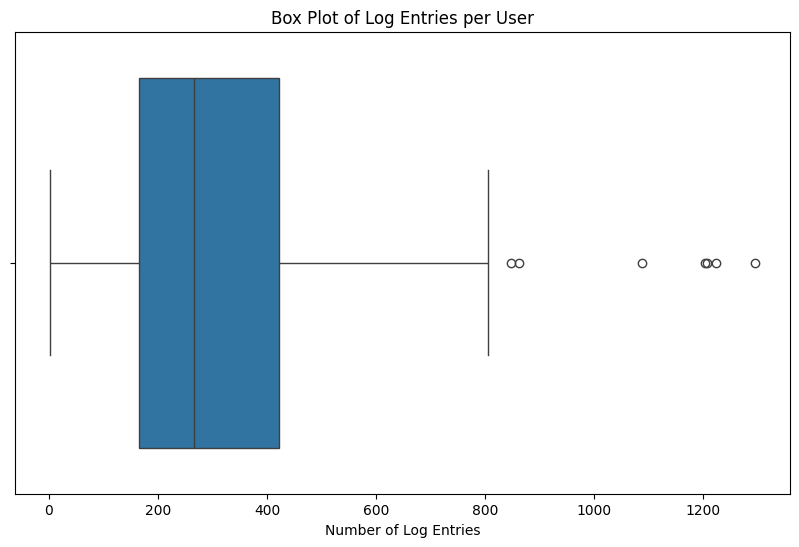

In [136]:
# plot user counts in a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=user_counts)
plt.title('Box Plot of Log Entries per User')
plt.xlabel('Number of Log Entries')
plt.show()

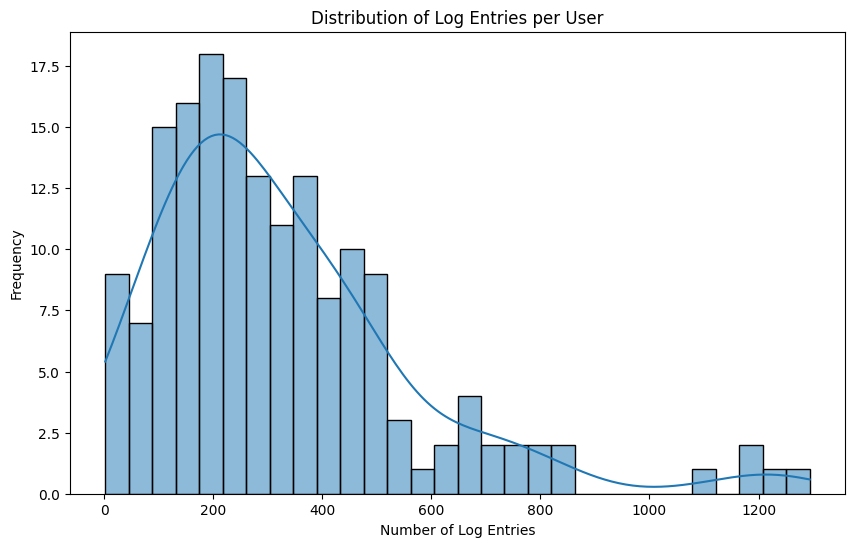

In [137]:
# distribution of log entries per user
plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=30, kde=True)
plt.title('Distribution of Log Entries per User')
plt.xlabel('Number of Log Entries')
plt.ylabel('Frequency')
plt.show()  

In [138]:
 # identify top 10 users with most log entries
top_users = user_counts.head(10)
print("Top 10 users with most log entries:")
print(top_users)

Top 10 users with most log entries:
Username
15925004@student.murdoch.edu.au    1294
15925153@student.murdoch.edu.au    1223
15925019@student.murdoch.edu.au    1206
15925125@student.murdoch.edu.au    1203
20220829@murdoch.edu.au            1087
15925085@student.murdoch.edu.au     861
15925028@student.murdoch.edu.au     847
15925115@student.murdoch.edu.au     805
15925136@student.murdoch.edu.au     780
15925088@student.murdoch.edu.au     750
Name: count, dtype: int64


In [139]:
# identify outliers in user log counts using IQR method
Q1 = user_counts.quantile(0.25)
Q3 = user_counts.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = user_counts[(user_counts < lower_bound) | (user_counts > upper_bound)]
print("Outliers in user log counts:")
print(outliers) 

Outliers in user log counts:
Username
15925004@student.murdoch.edu.au    1294
15925153@student.murdoch.edu.au    1223
15925019@student.murdoch.edu.au    1206
15925125@student.murdoch.edu.au    1203
20220829@murdoch.edu.au            1087
15925085@student.murdoch.edu.au     861
15925028@student.murdoch.edu.au     847
Name: count, dtype: int64


In [140]:
# idenfity all the users less than avearage log entries
below_average_users = user_counts[user_counts < average_logs_per_user]
print("Users with log entries below average:")
print(below_average_users)  

Users with log entries below average:
Username
15925038@student.murdoch.edu.au    324
15925009@student.murdoch.edu.au    317
15925046@student.murdoch.edu.au    311
15925036@student.murdoch.edu.au    310
15925026@student.murdoch.edu.au    302
                                  ... 
15925058@student.murdoch.edu.au     12
15925024@student.murdoch.edu.au      8
15925164@student.murdoch.edu.au      7
15925170@student.murdoch.edu.au      7
15925041@student.murdoch.edu.au      2
Name: count, Length: 99, dtype: int64


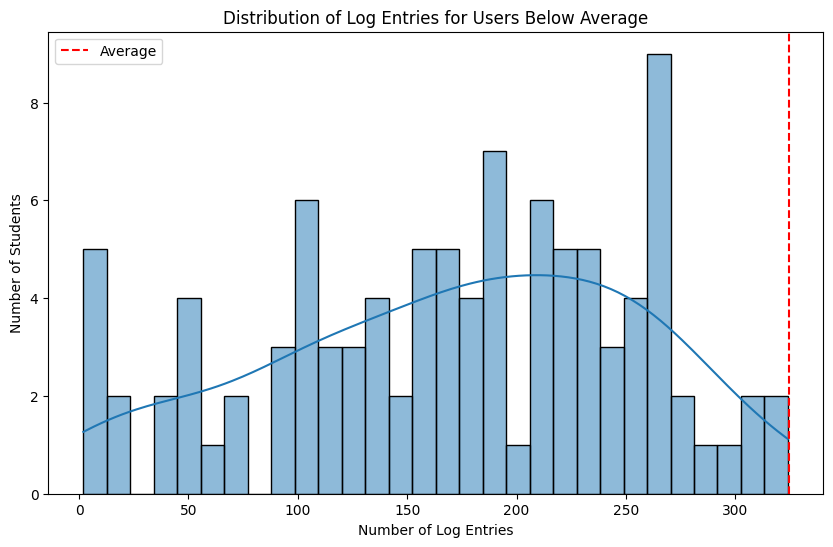

In [141]:
# plot user with log entries below average with mean line
plt.figure(figsize=(10, 6))
sns.histplot(below_average_users, bins=30, kde=True)
plt.title('Distribution of Log Entries for Users Below Average')
plt.xlabel('Number of Log Entries')
plt.ylabel('Number of Students') 
plt.axvline(average_logs_per_user, color='red', linestyle='--', label='Average')
plt.legend()    
plt.show()


In [142]:
# read ICT001 S1 2025 results all marks file 
results_data = pd.read_excel('ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx', sheet_name='Sheet1', engine='openpyxl')

In [143]:
results_data.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Penalty per day,Weight,Unnamed: 18,Penalty per day.1,Weight.1,Weight.2,Weight.3,Unnamed: 23,Unnamed: 24
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10,10,NaN,10,20,50,100,NaN,NaN
1,Person Id,Surname,Mark,Grade,Ass Ex 1,Ass Ex 2,Ass Ex 3,Ass Ex 4,Ass Ex 5,Ass Ex 6,...,Assignment 1 / 100,Delay (days),Ass 1 with Penalty /100,Ass 2 /100,Delay (days),Ass 2 with Penalty /100,Exam/ 100,Total/ 100,Rounded Total/ 100,Cal G
2,15925001,Surname001,52,P,NaN,40,30,95,50,100,...,76,NaN,76,52.85,NaN,52.85,43,52.17,52,P
3,15925002,Surname002,38,N,85,100,95,100,100,100,...,37,NaN,37,50.35,NaN,50.35,14.5,37.82,38,N
4,15925003,Surname003,2,N,NaN,NaN,25,25,0,20,...,3,NaN,3,NaN,NaN,0,0,1.7,2,N


In [144]:
print(results_data.columns)

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Penalty per day', 'Weight',
       'Unnamed: 18', 'Penalty per day.1', 'Weight.1', 'Weight.2', 'Weight.3',
       'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')


In [145]:
results_data = pd.read_excel(
    "ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx",
    header=2
)

results_data.head()

,Person Id,Surname,Mark,Grade,Ass Ex 1,Ass Ex 2,Ass Ex 3,Ass Ex 4,Ass Ex 5,Ass Ex 6,...,Assignment 1 / 100,Delay (days),Ass 1 with Penalty /100,Ass 2 /100,Delay (days).1,Ass 2 with Penalty /100,Exam/ 100,Total/ 100,Rounded Total/ 100,Cal G
0,15925001.0,Surname001,52.0,P,NaN,40.0,30.0,95.0,50.0,100.0,...,76,NaN,76.0,52.85,NaN,52.85,43.00,52.17,52,P
1,15925002.0,Surname002,38.0,N,85.0,100.0,95.0,100.0,100.0,100.0,...,37,NaN,37.0,50.35,NaN,50.35,14.50,37.82,38,N
2,15925003.0,Surname003,2.0,N,NaN,NaN,25.0,25.0,0.0,20.0,...,3,NaN,3.0,NaN,NaN,0.00,0.00,1.7,2,N
3,15925004.0,Surname004,46.0,S,60.0,40.0,45.0,35.0,75.0,55.0,...,31,NaN,31.0,68.00,NaN,68.00,36.25,45.825,46,S
4,15925005.0,Surname005,45.0,S,100.0,100.0,100.0,95.0,100.0,NaN,...,69,NaN,69.0,63.30,NaN,63.30,21.00,44.56,45,S


In [146]:
print(results_data.columns.tolist())

['Person Id', 'Surname', 'Mark', 'Grade', 'Ass Ex 1', 'Ass Ex 2', 'Ass Ex 3', 'Ass Ex 4', 'Ass Ex 5', 'Ass Ex 6', 'Ass Ex 7', 'Ass Ex 8', 'Ass Ex 9', 'Ass Ex 10', 'Weekly Lab Quizzes / 100', 'Assignment 1 / 100', 'Delay (days)', 'Ass 1 with Penalty /100', 'Ass 2 /100', 'Delay (days).1', 'Ass 2 with Penalty /100', 'Exam/ 100', 'Total/ 100', 'Rounded Total/ 100', 'Cal G']


In [147]:
results_data.columns = (
    results_data.columns
        .astype(str)
        .str.strip()
        .str.replace('\n', ' ', regex=False)
)

In [148]:
results_data = results_data.dropna(
    subset=['Person Id']
)

In [149]:
results_data['Person Id'] = (
    results_data['Person Id']
    .astype(str)
    .str.strip()
)

In [150]:
results_data.info()
results_data.describe()
results_data['Grade'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, 0 to 169
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person Id                 170 non-null    object 
 1   Surname                   170 non-null    object 
 2   Mark                      167 non-null    float64
 3   Grade                     170 non-null    object 
 4   Ass Ex 1                  149 non-null    float64
 5   Ass Ex 2                  152 non-null    float64
 6   Ass Ex 3                  137 non-null    float64
 7   Ass Ex 4                  129 non-null    float64
 8   Ass Ex 5                  127 non-null    float64
 9   Ass Ex 6                  125 non-null    float64
 10  Ass Ex 7                  118 non-null    float64
 11  Ass Ex 8                  114 non-null    float64
 12  Ass Ex 9                  103 non-null    float64
 13  Ass Ex 10                 105 non-null    float64
 14  Weekly Lab Quiz

Grade
N     73
P     23
C     19
D     16
S     14
SA    13
HD     9
DX     3
Name: count, dtype: int64

In [151]:
# merge results_data with user_counts to see if there is any correlation between log entries and grades
results_data['Person Id'] = results_data['Person Id'].astype(str)
user_counts.index = user_counts.index.astype(str)
merged_data = pd.merge(results_data, user_counts.rename('Log Entries'), left_on='Person Id', right_index=True, how='left')
print(merged_data[['Person Id', 'Grade', 'Log Entries']].head())    

    Person Id Grade  Log Entries
0  15925001.0     P          NaN
1  15925002.0     N          NaN
2  15925003.0     N          NaN
3  15925004.0     S          NaN
4  15925005.0     S          NaN


In [152]:
data_log['Person Id'] = (
    data_log['Username']
    .str.extract(r'(\d+)')
)

In [153]:
results_data['Person Id'] = (
    results_data['Person Id']
    .astype(str)
    .str.strip()
    .str.extract(r'(\d+)', expand=False)
)

results_data['Person Id'] = (
    results_data['Person Id']
    .astype(str)
    .str.strip()
    .str.extract(r'(\d+)', expand=False)
)

data_log['Person Id'] = (
    data_log['Person Id']
    .astype(str)
)

In [154]:
print(results_data['Person Id'].head())
print(data_log['Person Id'].head())

0    15925001
1    15925002
2    15925003
3    15925004
4    15925005
Name: Person Id, dtype: object
0    20220829
1    15925111
2    15925111
3    15925111
4    15925111
Name: Person Id, dtype: object


In [155]:
# build log_entries from existing data_log
log_entries = (
    data_log.assign(**{
        'Person Id': data_log['Person Id'].astype(str).str.extract(r'(\d+)', expand=False)
    })
    .dropna(subset=['Person Id'])
    .groupby('Person Id')
    .size()
    .reset_index(name='Log Entries')
)

# ensure same key format in results_data
results_data['Person Id'] = (
    results_data['Person Id'].astype(str).str.extract(r'(\d+)', expand=False)
)

merged_df = pd.merge(
    results_data[['Person Id', 'Grade']],
    log_entries[['Person Id', 'Log Entries']],
    on='Person Id',
    how='left'
)

merged_df['Log Entries'] = merged_df['Log Entries'].fillna(0).astype(int)

In [156]:
set(results_data['Person Id']).intersection(
    set(log_entries['Person Id'])
)

{'15925001',
 '15925002',
 '15925003',
 '15925004',
 '15925005',
 '15925006',
 '15925007',
 '15925008',
 '15925009',
 '15925010',
 '15925011',
 '15925012',
 '15925013',
 '15925014',
 '15925015',
 '15925016',
 '15925017',
 '15925018',
 '15925019',
 '15925020',
 '15925021',
 '15925022',
 '15925023',
 '15925024',
 '15925025',
 '15925026',
 '15925027',
 '15925028',
 '15925029',
 '15925030',
 '15925031',
 '15925032',
 '15925033',
 '15925034',
 '15925035',
 '15925036',
 '15925037',
 '15925038',
 '15925039',
 '15925040',
 '15925041',
 '15925042',
 '15925043',
 '15925044',
 '15925045',
 '15925046',
 '15925047',
 '15925048',
 '15925049',
 '15925050',
 '15925051',
 '15925052',
 '15925053',
 '15925054',
 '15925055',
 '15925056',
 '15925057',
 '15925058',
 '15925059',
 '15925060',
 '15925061',
 '15925062',
 '15925063',
 '15925064',
 '15925065',
 '15925066',
 '15925067',
 '15925068',
 '15925069',
 '15925070',
 '15925071',
 '15925072',
 '15925073',
 '15925074',
 '15925075',
 '15925076',
 '15925077',

In [157]:
merged_df['Log Entries'].isna().sum()

np.int64(0)

In [158]:
merged_df.groupby('Grade')['Log Entries'].mean()

Grade
C     298.789474
D     460.250000
DX    447.000000
HD    432.000000
N     226.520548
P     367.000000
S     394.214286
SA    381.461538
Name: Log Entries, dtype: float64

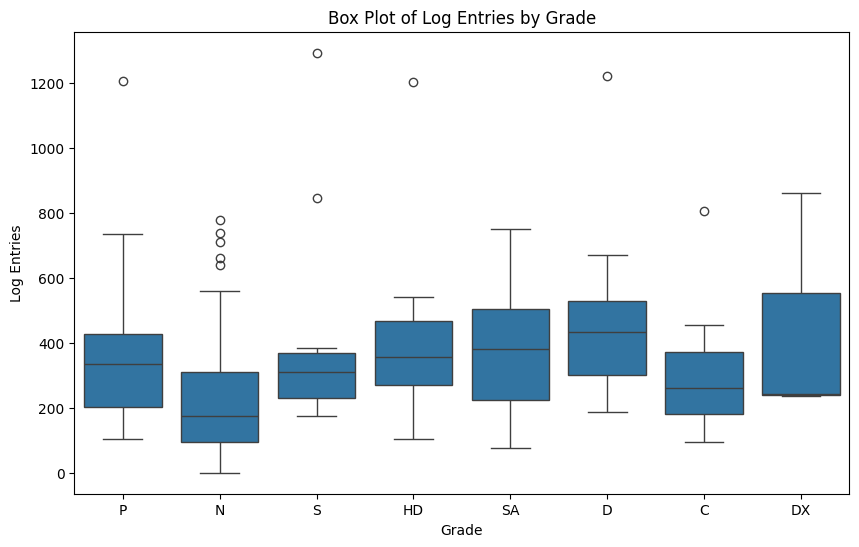

In [159]:
# check corelation between log entries and grades
plt.figure(figsize=(10, 6))
sns.boxplot(x='Grade', y='Log Entries', data=merged_df)
plt.title('Box Plot of Log Entries by Grade')
plt.xlabel('Grade') 
plt.show()

In [160]:
# check what type of log entries for SA grade students
sa_students = merged_df[merged_df['Grade'] == 'SA']
sa_student_ids = sa_students['Person Id'].tolist()
sa_logs = data_log[data_log['Person Id'].isin(sa_student_ids)]
print(sa_logs.head())   

                 Time   User full name                         Username  \
1  20/09/25, 19:30:02  John Surname111  15925111@student.murdoch.edu.au   
2  20/09/25, 19:29:35  John Surname111  15925111@student.murdoch.edu.au   
3  20/09/25, 19:29:08  John Surname111  15925111@student.murdoch.edu.au   
4  20/09/25, 19:29:04  John Surname111  15925111@student.murdoch.edu.au   
5  20/09/25, 19:28:42  John Surname111  15925111@student.murdoch.edu.au   

  Affected user                                  Event context Component  \
1             -  Unit: ICT001 Theory of Programming (S1, 2025)    System   
2             -                    File: Lab description (PDF)      File   
3             -         File: Solutions (Hidden from Students)      File   
4             -  Unit: ICT001 Theory of Programming (S1, 2025)    System   
5             -                    File: Lab description (PDF)      File   

           Event name                                        Description  \
1         Unit v

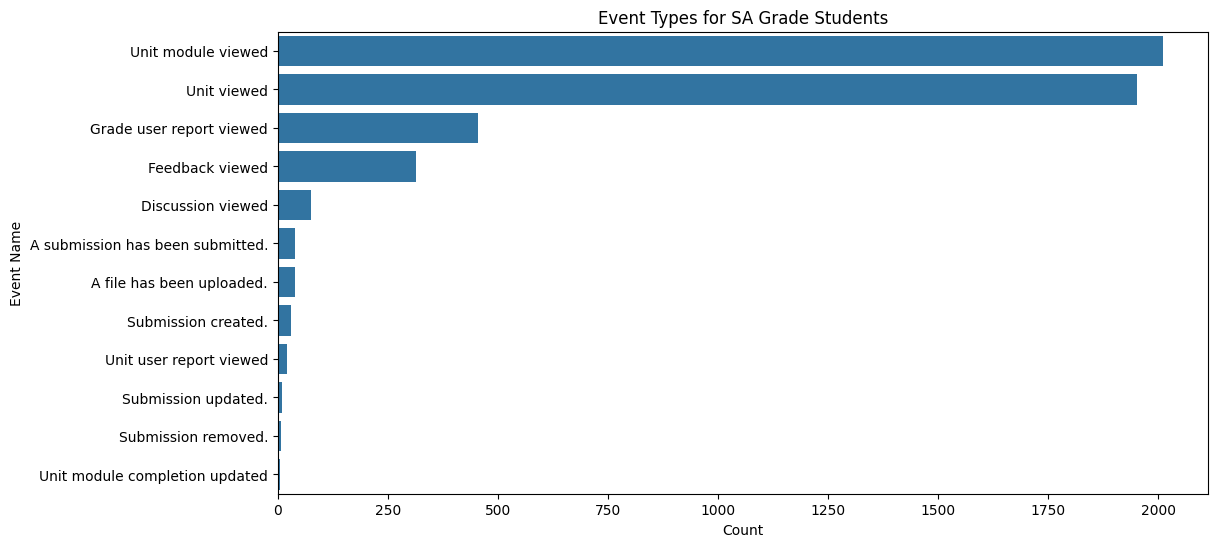

In [161]:
# plot event types for SA grade students
plt.figure(figsize=(12, 6))
sns.countplot(y='Event name', data=sa_logs, order=sa_logs['Event name'].value_counts().index)
plt.title('Event Types for SA Grade Students')
plt.xlabel('Count')
plt.ylabel('Event Name')
plt.show()

In [162]:
sa_logs = sa_logs.copy()
sa_logs['Time'] = pd.to_datetime(sa_logs['Time'], errors='coerce', dayfirst=True)
sa_logs['Date'] = sa_logs['Time'].dt.date

sa_daily = (
    sa_logs
    .groupby(['Date', 'Event name'])
    .size()
    .reset_index(name='Count')
)

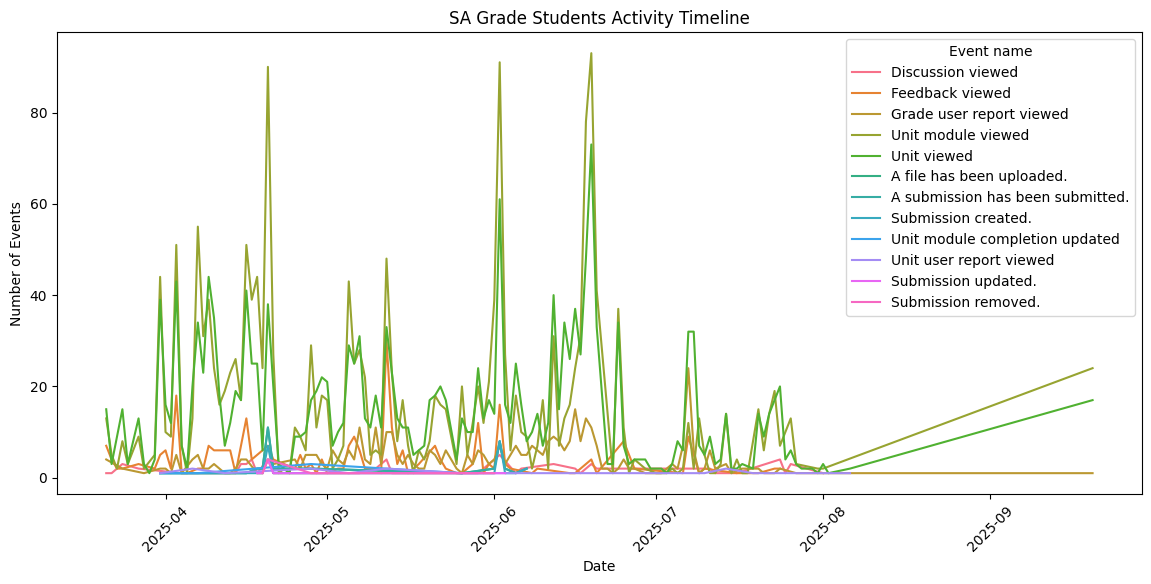

In [163]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=sa_daily,
    x='Date',
    y='Count',
    hue='Event name'
)

plt.title('SA Grade Students Activity Timeline')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

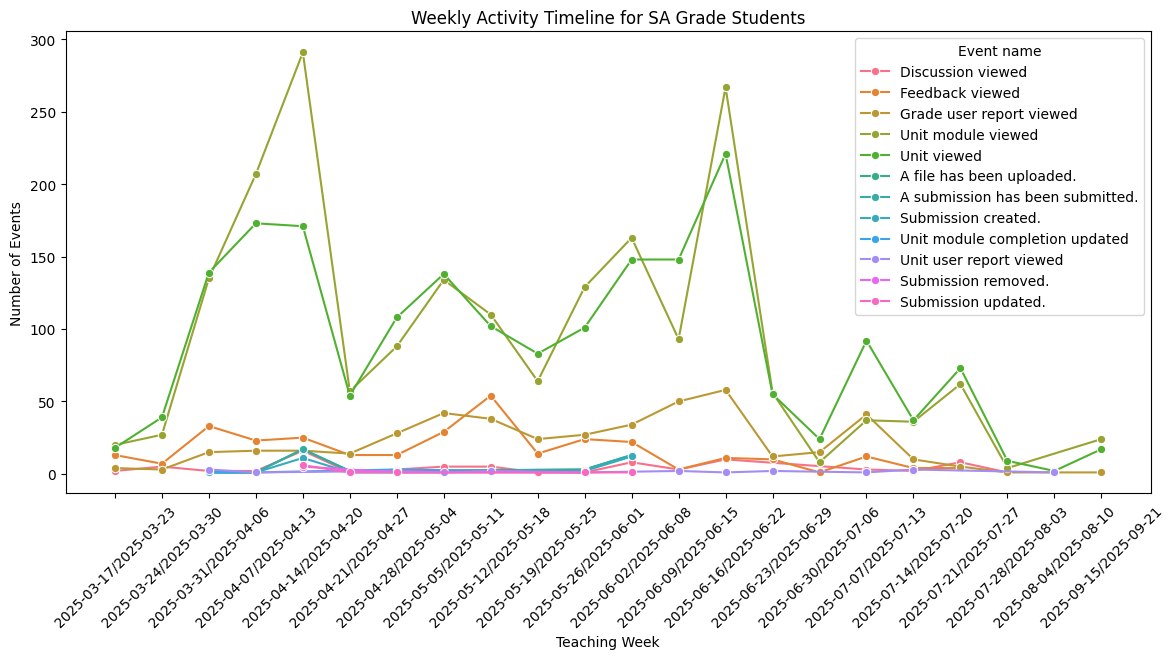

In [164]:
sa_logs['Week'] = sa_logs['Time'].dt.to_period('W').astype(str)

sa_weekly = (
    sa_logs
    .groupby(['Week', 'Event name'])
    .size()
    .reset_index(name='Count')
)

# plot weekly activity timeline for SA grade students
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=sa_weekly,
    x='Week',
    y='Count',
    hue='Event name',
    marker='o'
)

plt.title('Weekly Activity Timeline for SA Grade Students')
plt.xlabel('Teaching Week')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

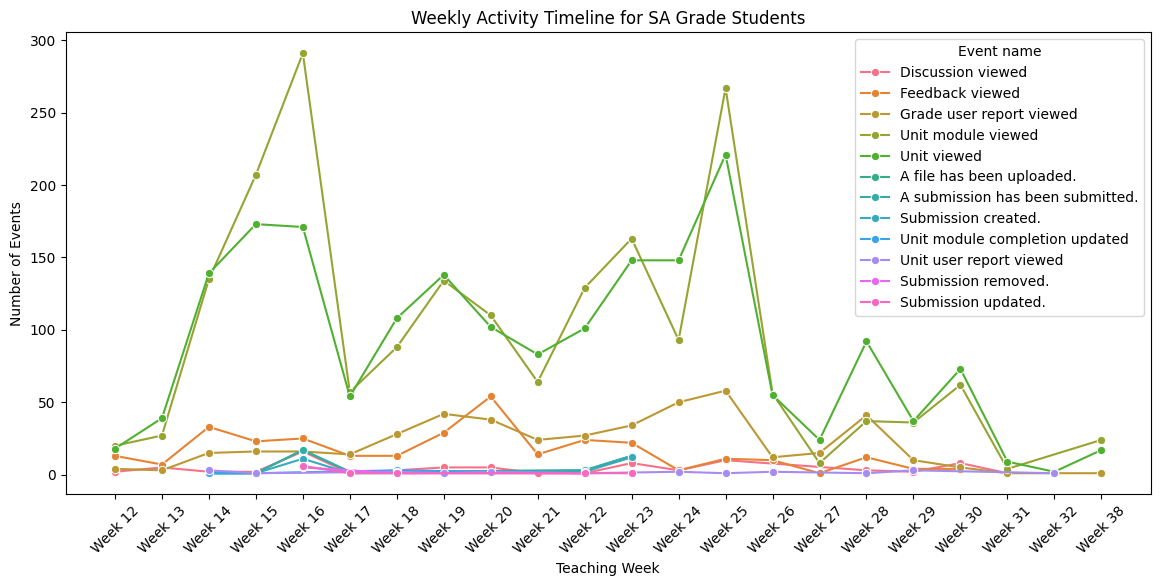

In [165]:
sa_logs['Week'] = sa_logs['Time'].dt.to_period('W').astype(str)

sa_weekly = (
    sa_logs
    .groupby(['Week', 'Event name'])
    .size()
    .reset_index(name='Count')
)

# plot weekly activity timeline for SA grade students
plt.figure(figsize=(14, 6)) 
# name weeks as week numbers
sa_weekly['Week'] = (
    pd.to_datetime(sa_weekly['Week'].str.split('/').str[0])
    .dt.isocalendar().week
    .astype(int)
    .map(lambda w: f"Week {w}")
)
sns.lineplot(
    data=sa_weekly,
    x='Week',
    y='Count',
    hue='Event name',
    marker='o'
)

plt.title('Weekly Activity Timeline for SA Grade Students')
plt.xlabel('Teaching Week')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

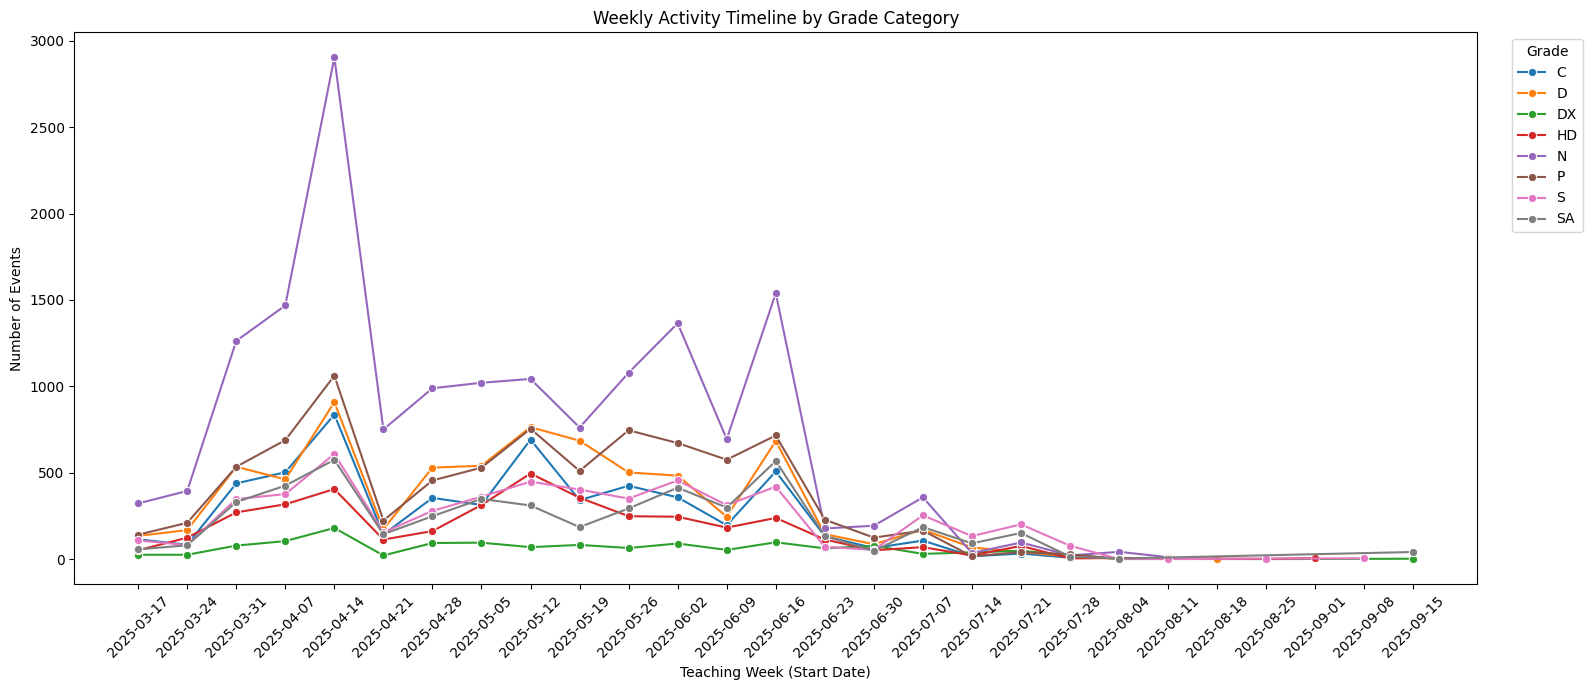

In [166]:
# compare weekly activity timeline for all grade categories (SA, P, D, HD, N, DX, etc.)
compare_students = merged_df[['Person Id', 'Grade']].drop_duplicates().copy()
compare_students = compare_students.dropna(subset=['Grade'])
compare_students['Grade'] = compare_students['Grade'].astype(str).str.strip()

compare_logs = pd.merge(
    data_log.copy(),
    compare_students,
    on='Person Id',
    how='inner'
 )

compare_logs['Time'] = pd.to_datetime(compare_logs['Time'], errors='coerce', dayfirst=True)
compare_logs = compare_logs.dropna(subset=['Time'])

compare_logs['WeekStart'] = compare_logs['Time'].dt.to_period('W').dt.start_time
compare_weekly = (
    compare_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Count')
 )

compare_weekly['Week'] = compare_weekly['WeekStart'].dt.strftime('%Y-%m-%d')

grade_order = sorted(compare_weekly['Grade'].unique().tolist())
compare_weekly['Grade'] = pd.Categorical(
    compare_weekly['Grade'],
    categories=grade_order,
    ordered=True
 )

plt.figure(figsize=(16, 7))
sns.lineplot(
    data=compare_weekly.sort_values(['WeekStart', 'Grade']),
    x='Week',
    y='Count',
    hue='Grade',
    marker='o'
 )
plt.title('Weekly Activity Timeline by Grade Category')
plt.xlabel('Teaching Week (Start Date)')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

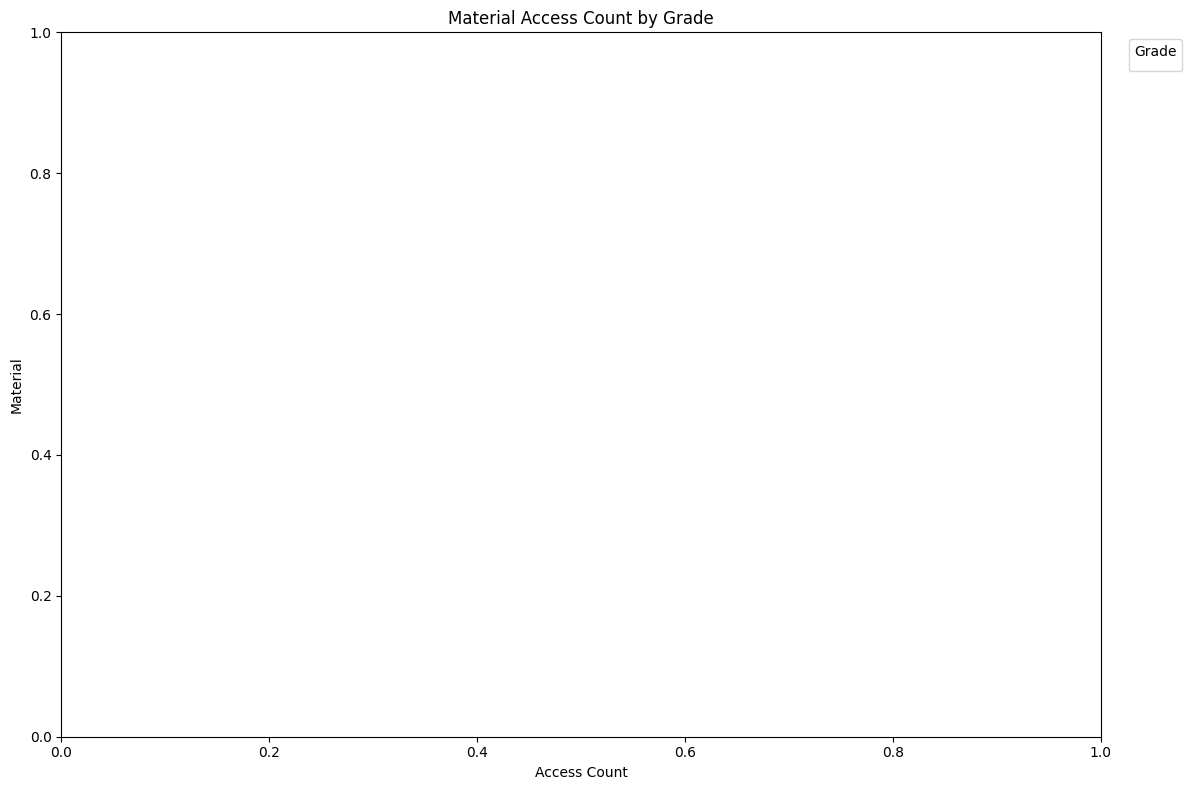

In [167]:
# group by material and grade to see if there is any correlation between material access and grades
material_access = pd.merge(
    data_log.copy(),
    compare_students,
    on='Person Id',
    how='inner'
)       
material_access['Material'] = material_access['Description'].str.extract(r"accessed material '([^']+)'", expand=False)
material_access = material_access.dropna(subset=['Material'])
material_grade = (
    material_access
    .groupby(['Material', 'Grade'])
    .size()
    .reset_index(name='Access Count')
)
material_grade['Grade'] = material_grade['Grade'].astype(str).str.strip()
grade_order = sorted(material_grade['Grade'].unique().tolist())
material_grade['Grade'] = pd.Categorical(
    material_grade['Grade'],
    categories=grade_order,
    ordered=True
)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=material_grade.sort_values(['Material', 'Grade']),
    x='Access Count',
    y='Material',
    hue='Grade'
)
plt.title('Material Access Count by Grade')
plt.xlabel('Access Count')
plt.ylabel('Material')
plt.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()